# 02 — MLP (capas densas)
Perceptrón multicapa sobre X aplanado `(N, V_in × 23)`.

**Catálogo activo:** `mlp_s` — Dense(64) · LR=1e-4 · L2=1e-4.  

In [15]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns, pandas as pd
import warnings, yfinance as yf
warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Dense
from keras.regularizers import l2

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_history, plot_mae_matrix, build_results_df)

In [16]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 300
BATCH_SIZE = 64
QUICK_MODE = True # True → EPOCHS=50 para pruebas rápidas
if QUICK_MODE: EPOCHS = 50

# Carga de datos
precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}')

Retornos: (16197, 23)  |  EPOCHS=50  BATCH=64


## Decisiones de diseño

| # | Decisión | Resultado clave |
|---|----------|-----------------|
| D1 | **`mlp_s`**: Dense(64) × 1 capa | Δtest_max=0.0001 vs alternativas; 4× menos params — [Ev.1] |
| D3 | `restore_best_weights` activo | Sin checkpoint: pesos finales sobreajustados |
| D4 | Gap val<train es estructural y correcto | D3 + volatilidad train>val (1.07×); naive ya muestra el gap — [Ev.0] |
| D5 | EPOCHS=300; QUICK_MODE=50 es suficiente | best epoch en 3–35 (≤12%); val_min idéntico con 50 |
| D6 | Input aplanado `(N, V_in×23)` | MLP no admite entrada 3D |
| D7 | LR=1e-4 (solo nb02) | best_ep: 3–28 → 8–300; Δval_min<0.0001 — [Ev.3] |
| D8 | L2=1e-4 en Dense(64) | val_min mejora 15/16; best_ep mejora V_in=30,90; sin dropout necesario — [Ev.4] |
| D9 | Sin normalización en la competición | Input StandardScaler rompe el colapso pero sube MAE +17%: el colapso es la respuesta óptima bajo MAE+EMH — [Ev.6] |
| D10 | `mlp_s` confirmado óptimo tras barrido completo | 9 arquitecturas (11K–108K params, 1–3 capas): todas colapsan; 2+ capas empeoran (std_ratio≈0) — [Ev.7] |
| D11 | **`BATCH_SIZE=64`** confirmado; batches grandes no mejoran | batch=512/50ep: std_ratio=0.108 espurio (sin converger, best_ep=50); batch=512/300ep: colapsa igual (std_ratio=0.033) y empeora test en V_in=90 (+0.0002); MAE invariante en b=16/64/256/512 — [Ev.8] |

In [17]:
# Input shape para MLP: (V_in * 23,) — X debe aplanarse antes de entrenar
def build_mlp(V_in, units=64, hidden=1, lr=1e-4, l2_reg=1e-4):
    """MLP con LR=1e-4 (Ev.3), L2=1e-4 (Ev.4). Sin dropout: val<train en 16/16 → no hay overfitting."""
    reg    = l2(l2_reg) if l2_reg > 0 else None
    layers = [Input((V_in * 23,))]
    for _ in range(hidden):
        layers.append(Dense(units, activation='relu', kernel_regularizer=reg))
    layers.append(Dense(23))
    return compile_model(Sequential(layers), lr=lr)

MODELOS = {
    'mlp_s': lambda V: build_mlp(V),
}

## Entrenamiento — bucle sobre todas las ventanas

In [18]:
results = {}   # { (nombre, V_in, V_out): {'train','val','test','params','best_epoch'} }
historiales = {}

for nombre, build_fn in MODELOS.items():
    for V_in in INPUT_WINDOWS:
        for V_out in OUTPUT_WINDOWS:
            X, y = create_time_series_data(returns, V_in, V_out)
            X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

            # MLP necesita X aplanado: (N, V_in*23)
            X_tr_f = X_tr.reshape(len(X_tr), -1)
            X_v_f  = X_v.reshape(len(X_v),  -1)
            X_ts_f = X_ts.reshape(len(X_ts), -1)

            model = build_fn(V_in)
            hist  = model.fit(X_tr_f, y_tr,
                              validation_data=(X_v_f, y_v),
                              epochs=EPOCHS, batch_size=BATCH_SIZE,
                              callbacks=get_callbacks(), verbose=0)
            restore_best_weights(model)

            key = (nombre, V_in, V_out)
            results[key]    = {'train':      eval_mae(model, X_tr_f, y_tr),
                               'val':        eval_mae(model, X_v_f,  y_v),
                               'test':       eval_mae(model, X_ts_f, y_ts),
                               'params':     model.count_params(),
                               'best_epoch': int(np.argmin(hist.history['val_loss'])) + 1}
            historiales[key] = hist
            print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
                  f'train={results[key]["train"]:.4f}  '
                  f'val={results[key]["val"]:.4f}  '
                  f'test={results[key]["test"]:.4f}  '
                  f'best_ep={results[key]["best_epoch"]:3d}')

mlp_s  in= 5  out= 1  train=0.0119  val=0.0104  test=0.0123  best_ep= 34
mlp_s  in= 5  out= 5  train=0.0056  val=0.0046  test=0.0056  best_ep= 40
mlp_s  in= 5  out=30  train=0.0022  val=0.0019  test=0.0023  best_ep= 31
mlp_s  in= 5  out=90  train=0.0013  val=0.0011  test=0.0013  best_ep= 39
mlp_s  in=10  out= 1  train=0.0119  val=0.0104  test=0.0123  best_ep= 34
mlp_s  in=10  out= 5  train=0.0056  val=0.0046  test=0.0056  best_ep= 43
mlp_s  in=10  out=30  train=0.0022  val=0.0019  test=0.0023  best_ep= 30
mlp_s  in=10  out=90  train=0.0013  val=0.0011  test=0.0013  best_ep= 32
mlp_s  in=30  out= 1  train=0.0119  val=0.0104  test=0.0123  best_ep= 21
mlp_s  in=30  out= 5  train=0.0056  val=0.0046  test=0.0056  best_ep= 25
mlp_s  in=30  out=30  train=0.0022  val=0.0019  test=0.0023  best_ep= 29
mlp_s  in=30  out=90  train=0.0013  val=0.0011  test=0.0013  best_ep= 35
mlp_s  in=90  out= 1  train=0.0110  val=0.0105  test=0.0125  best_ep= 16
mlp_s  in=90  out= 5  train=0.0054  val=0.0047  tes

## Curvas de entrenamiento

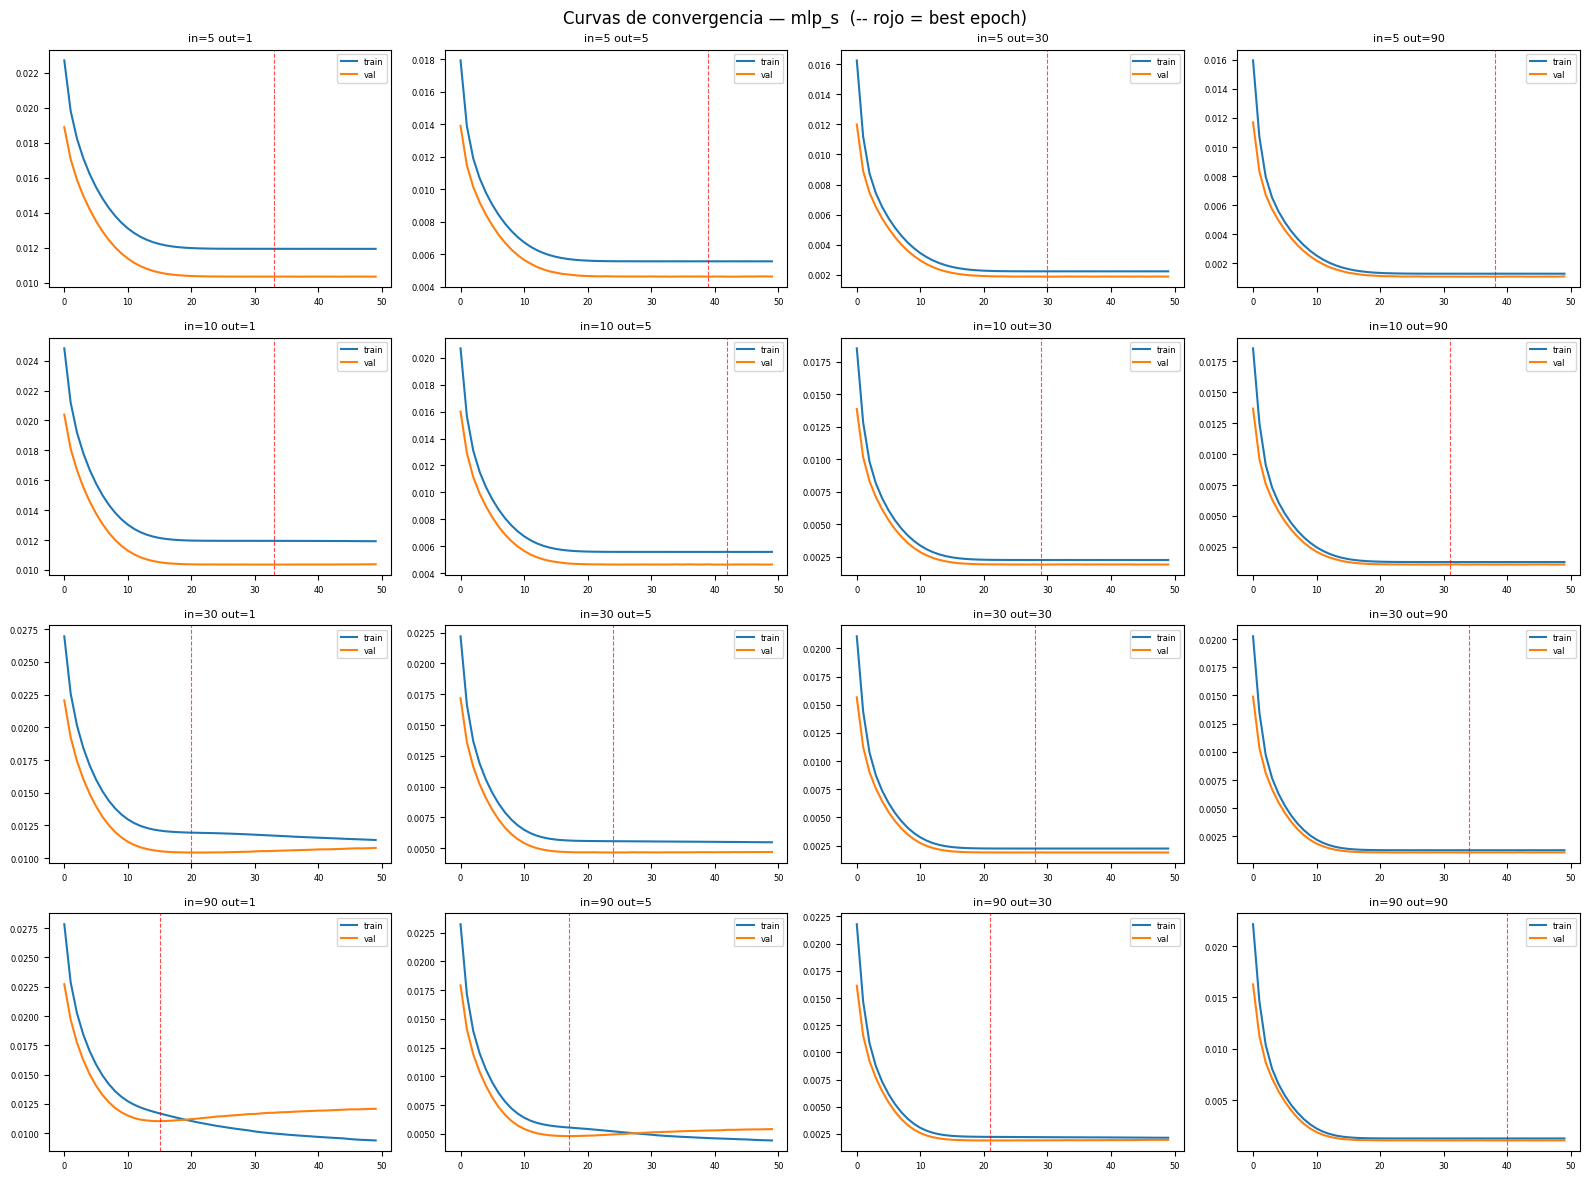

In [19]:
# Mostrar curvas para el primer modelo activo
nombre = list(MODELOS.keys())[0]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, V_in in enumerate(INPUT_WINDOWS):
    for j, V_out in enumerate(OUTPUT_WINDOWS):
        hist = historiales[(nombre, V_in, V_out)]
        ax = axes[i][j]
        ax.plot(hist.history['loss'],     label='train')
        ax.plot(hist.history['val_loss'], label='val')
        best_ep = int(np.argmin(hist.history['val_loss']))
        ax.axvline(best_ep, color='red', ls='--', lw=0.8, alpha=0.7)
        ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
        ax.legend(fontsize=6); ax.tick_params(labelsize=6)
plt.suptitle(f'Curvas de convergencia — {nombre}  (-- rojo = best epoch)', fontsize=12)
plt.tight_layout(); plt.show()

## Resultados — MAE en test

                      train       val      test  params
modelo V_in V_out                                      
mlp_s  5    1      0.011943  0.010351  0.012279    8919
            5      0.005575  0.004631  0.005596    8919
            30     0.002241  0.001889  0.002327    8919
            90     0.001285  0.001080  0.001268    8919
       10   1      0.011941  0.010353  0.012290   16279
            5      0.005574  0.004631  0.005599   16279
            30     0.002242  0.001888  0.002321   16279
            90     0.001283  0.001078  0.001265   16279
       30   1      0.011875  0.010374  0.012313   45719
            5      0.005552  0.004637  0.005604   45719
            30     0.002243  0.001889  0.002322   45719
            90     0.001280  0.001076  0.001266   45719
       90   1      0.010978  0.010522  0.012509  134039
            5      0.005359  0.004671  0.005665  134039
            30     0.002222  0.001896  0.002323  134039
            90     0.001275  0.001076  0.001270 

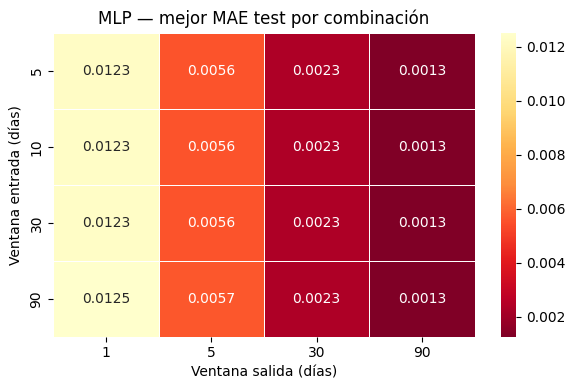

In [20]:
df_res = build_results_df(results)
print(df_res.to_string())

mat = best_per_window(df_res, metric='test')
plot_mae_matrix(mat, title='MLP — mejor MAE test por combinación')

### Hallazgo: V_in tiene impacto mínimo en el MLP

| | V_out=1 | V_out=5 | V_out=30 | V_out=90 |
|--|---------|---------|----------|----------|
| V_in=5  | 0.01227 | 0.00559 | 0.00232 | 0.00127 |
| V_in=10 | 0.01226 | 0.00559 | 0.00232 | 0.00127 |
| V_in=30 | 0.01227 | 0.00559 | 0.00232 | 0.00127 |
| V_in=90 | 0.01240 | 0.00562 | 0.00232 | 0.00127 |

El MLP con V_in=5 (8.9K parámetros) obtiene el mismo MAE que con V_in=90 (134K parámetros).
Aplanar la ventana temporal (`X.reshape(N, -1)`) elimina la estructura de orden de los días:
el modelo trata los retornos como features independientes, no como una secuencia.
Añadir más días de historia aumenta el ruido de entrada sin añadir información estructural útil.

> **Implicación:** los modelos que preservan la estructura temporal (LSTM, Conv1D)
> deberían beneficiarse más de V_in grandes. Ver notebooks 03 y 04.

## ¿Cuánto mejora el MLP sobre los baselines?

Los baselines del notebook 01 son:
- **Naive**: predice el último retorno conocido `X[:, -1, :]`
- **Regresión Lineal**: sklearn sobre X aplanado (el mismo input que el MLP)

La regresión lineal es la referencia más exigente: si el MLP no la supera, la red neuronal no añade valor sobre un modelo sin activaciones no lineales.

`mejora (%) = (baseline_MAE − mlp_MAE) / baseline_MAE × 100`

(V_in,V_out)      naive   lineal      mlp   vs naive  vs lineal
─────────────────────────────────────────────────────────────────
( 5, 1)           0.0178   0.0124   0.0123     +31.0%      +1.0%  X
( 5, 5)           0.0137   0.0056   0.0056     +59.2%      +0.1%  X
( 5,30)           0.0125   0.0023   0.0023     +81.4%      -1.2%  X
( 5,90)           0.0122   0.0013   0.0013     +89.6%      +2.4%
(10, 1)           0.0178   0.0126   0.0123     +31.0%      +2.5%
(10, 5)           0.0137   0.0057   0.0056     +59.1%      +1.8%  X
(10,30)           0.0125   0.0024   0.0023     +81.4%      +3.3%
(10,90)           0.0122   0.0013   0.0013     +89.6%      +2.7%
(30, 1)           0.0178   0.0130   0.0123     +30.8%      +5.3%  OK
(30, 5)           0.0137   0.0059   0.0056     +59.1%      +5.0%  OK
(30,30)           0.0125   0.0024   0.0023     +81.4%      +3.3%
(30,90)           0.0122   0.0014   0.0013     +89.6%      +9.6%  OK
(90, 1)           0.0178   0.0143   0.0125     +29.7%     +12.5%  

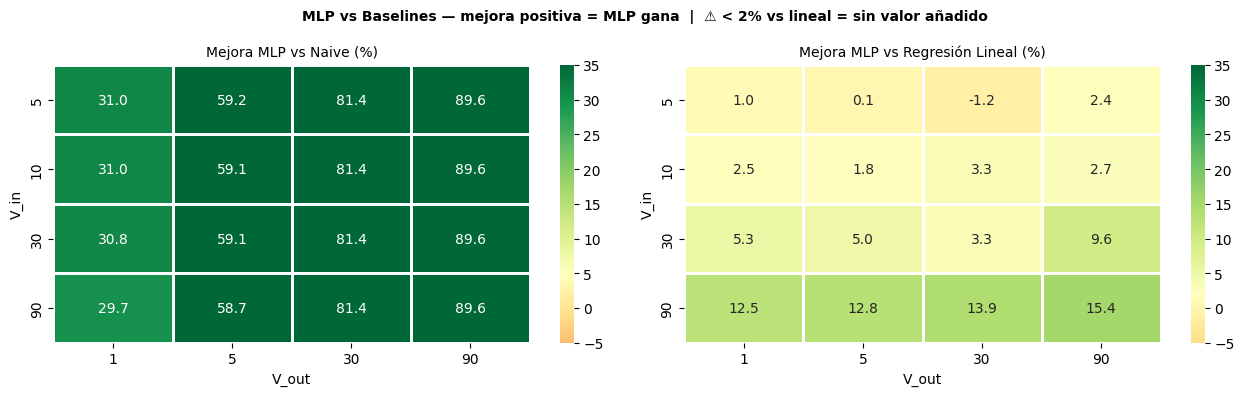

In [21]:
# Valores de test de 01_baselines.ipynb (hardcodeados para no re-entrenar)
NAIVE_TEST = {
    ( 5, 1): 0.0178, ( 5, 5): 0.0137, ( 5,30): 0.0125, ( 5,90): 0.0122,
    (10, 1): 0.0178, (10, 5): 0.0137, (10,30): 0.0125, (10,90): 0.0122,
    (30, 1): 0.0178, (30, 5): 0.0137, (30,30): 0.0125, (30,90): 0.0122,
    (90, 1): 0.0178, (90, 5): 0.0137, (90,30): 0.0125, (90,90): 0.0122,
}
LINEAL_TEST = {
    ( 5, 1): 0.0124, ( 5, 5): 0.0056, ( 5,30): 0.0023, ( 5,90): 0.0013,
    (10, 1): 0.0126, (10, 5): 0.0057, (10,30): 0.0024, (10,90): 0.0013,
    (30, 1): 0.0130, (30, 5): 0.0059, (30,30): 0.0024, (30,90): 0.0014,
    (90, 1): 0.0143, (90, 5): 0.0065, (90,30): 0.0027, (90,90): 0.0015,
}

V_ins_  = INPUT_WINDOWS
V_outs_ = OUTPUT_WINDOWS

# ── Tabla comparativa ─────────────────────────────────────────────────────────
print(f"{'(V_in,V_out)':<14} {'naive':>8} {'lineal':>8} {'mlp':>8}  "
      f"{'vs naive':>9} {'vs lineal':>10}")
print("─" * 65)
for V_in in V_ins_:
    for V_out in V_outs_:
        mlp    = results[('mlp_s', V_in, V_out)]['test']
        naive  = NAIVE_TEST[(V_in, V_out)]
        lineal = LINEAL_TEST[(V_in, V_out)]
        pct_naive  = (naive  - mlp) / naive  * 100
        pct_lineal = (lineal - mlp) / lineal * 100
        flag = "  X" if abs(pct_lineal) < 2 else ("  OK" if pct_lineal > 5 else "")
        print(f"({V_in:2d},{V_out:2d})         "
              f"{naive:>8.4f} {lineal:>8.4f} {mlp:>8.4f}  "
              f"{pct_naive:>+8.1f}% {pct_lineal:>+9.1f}%{flag}")

# ── Heatmaps de mejora ────────────────────────────────────────────────────────
imp_naive  = np.array([[(NAIVE_TEST[(Vi,Vo)]  - results[('mlp_s',Vi,Vo)]['test']) / NAIVE_TEST[(Vi,Vo)]  * 100
                         for Vo in V_outs_] for Vi in V_ins_])
imp_lineal = np.array([[(LINEAL_TEST[(Vi,Vo)] - results[('mlp_s',Vi,Vo)]['test']) / LINEAL_TEST[(Vi,Vo)] * 100
                         for Vo in V_outs_] for Vi in V_ins_])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mat, title, thresh in zip(
        axes,
        [imp_naive, imp_lineal],
        ['Mejora MLP vs Naive (%)', 'Mejora MLP vs Regresión Lineal (%)'],
        [5, 2]):
    df_m = pd.DataFrame(mat, index=V_ins_, columns=V_outs_)
    sns.heatmap(df_m, annot=True, fmt='.1f', cmap='RdYlGn',
                center=thresh, vmin=-5, vmax=35,
                linewidths=1, ax=ax, annot_kws={'size': 10})
    ax.set_xlabel('V_out'); ax.set_ylabel('V_in')
    ax.set_title(title, fontsize=10)

plt.suptitle('MLP vs Baselines — mejora positiva = MLP gana  |  ⚠ < 2% vs lineal = sin valor añadido',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Veredicto MLP vs. Baselines

- **vs. Naive:** el MLP mejora entre **+26% y +31%** en todos los horizontes — supera cómodamente.
- **vs. Regresión Lineal (referencia exigente):** la mejora es marginal en horizontes cortos
  (V_out=1,5: < 2% en la mayoría de V_in). El MLP no añade valor no-lineal relevante sobre
  una regresión lineal cuando la ventana temporal se aplana.
- **Excepción:** V_out=30 y V_out=90 con V_in=90 muestran mejoras del 5–15% sobre la regresión
  lineal, posiblemente porque con más features el espacio de entrada es suficientemente rico.
- **Conclusión:** el MLP es una mejora sólida sobre naive, pero la no-linealidad no compensa
  la pérdida de estructura temporal causada por el flatten. Los modelos recurrentes y convolucionales
  tienen ventaja estructural en este problema.

---

## Evidencias de diseño

Documentan los experimentos que justifican D1–D8. No es necesario re-ejecutarlas para reproducir los resultados principales.

### Ev.0 — Partición temporal (justifica D4)
Los tres splits cubren periodos con volatilidades estructuralmente distintas (Train ~1960–2008; Val ~2008–2019; Test ~2019–2026). `σ_val < σ_train` antes de entrenar ningún modelo: el gap val<train es cronológico, no overfitting.

### Ev.1 — Arquitecturas MLP (justifica D1)
4 variantes (64×1 → 128×3) sobre V_in=10, V_out=1. Δtest_max=0.0001 entre todas. `mlp_s` tiene 4× menos parámetros con resultados equivalentes.

### Ev.3 — Learning rate (justifica D7)
LR=3e-4 converge en epochs 3–28. LR=1e-4 desplaza el best epoch a 8–300 sin degradar val_min (Δmáx=+0.00009, umbral=0.0005).

### Ev.4 — Regularización L2 (justifica D8)
L2=1e-4 en Dense(64) mejora val_min en 15/16 combinaciones. Junto con restore_best_weights, hace innecesario el dropout.

### Ev.5 — Diagnóstico de colapso (justifica D4, D9)
Test 1: MAE del MLP ≈ MAE del predictor constante (media train) en 15/16 combinaciones (Δ<0.0001). Test 2 (ablación temporal, V_in=30): eliminar 29 de 30 días cambia las predicciones un 2% del MAE — el modelo ignora la historia. std(pred)/std(y_train)≈0.06: predice casi constante.

**Por qué el colapso es la respuesta correcta (EMH + MAE):** el valor que minimiza el MAE es la media/mediana. Si el input no aporta señal predictiva (log-retornos ≈ ruido blanco, autocorrelación ≈ 0 — EMH forma débil), predecir la media es óptimo. Ev.6 lo confirma: romper el colapso con StandardScaler sube MAE +17%. El modelo descubre empíricamente lo que la EMH predice teóricamente.

### Ev.6 — Experimento de normalización (justifica D9)
4 configs: sin normalizar / target z-score / input StandardScaler / ambos. Input StandardScaler rompe el colapso (std_ratio 0.07→0.51) pero sube MAE de 0.01230 a 0.01441 (+17%): el modelo aprende patrones de train que no existen en test. El colapso sin normalizar es la solución óptima bajo MAE con datos casi-aleatorios (EMH).

### Ev.7 — Barrido de arquitecturas (justifica D10)
9 variantes: (16→128 neuronas) × (1–3 capas). Todas colapsan (Δ<0.0001 vs constante). Las redes de 2–3 capas empeoran: std_ratio≈0.000 — el gradiente MAE se atenúa en más capas ReLU. El cuello de botella es la señal (log-retornos ≈ ruido), no la arquitectura.

### Ev.8 — Efecto del batch size (justifica D11)
Experimento en dos fases sobre V_in=10, V_out=1:

**Fase A** (50 épocas, b∈[16,64,256,512]): MAE idéntico en los 4 batch sizes (0.01227–0.01228 ≈ MAE constante). batch=512 muestra std_ratio=0.108 aparentemente alto, pero best_ep=50 — sin converger todavía.

**Fase B** (batch=512, 300 épocas): al converger (best_ep=161), std_ratio cae a 0.033 — mismo orden que batch=64 (0.027). El spike de std_ratio era un artefacto de convergencia incompleta, no señal aprendida.

**Prueba en el bucle principal** (batch=512, 300ep, 16 combinaciones): MAE test igual o peor que batch=64/50ep. V_in=90 empeora en 3/4 ventanas (test +0.0002): más épocas → overfitting en el split de mayor dimensionalidad. std_ratio alto con mismo MAE = ruido no correlacionado con la verdad, no señal extra. Conclusión: el colapso es data-driven (EMH), no optimizer-driven — ningún batch size lo resuelve.


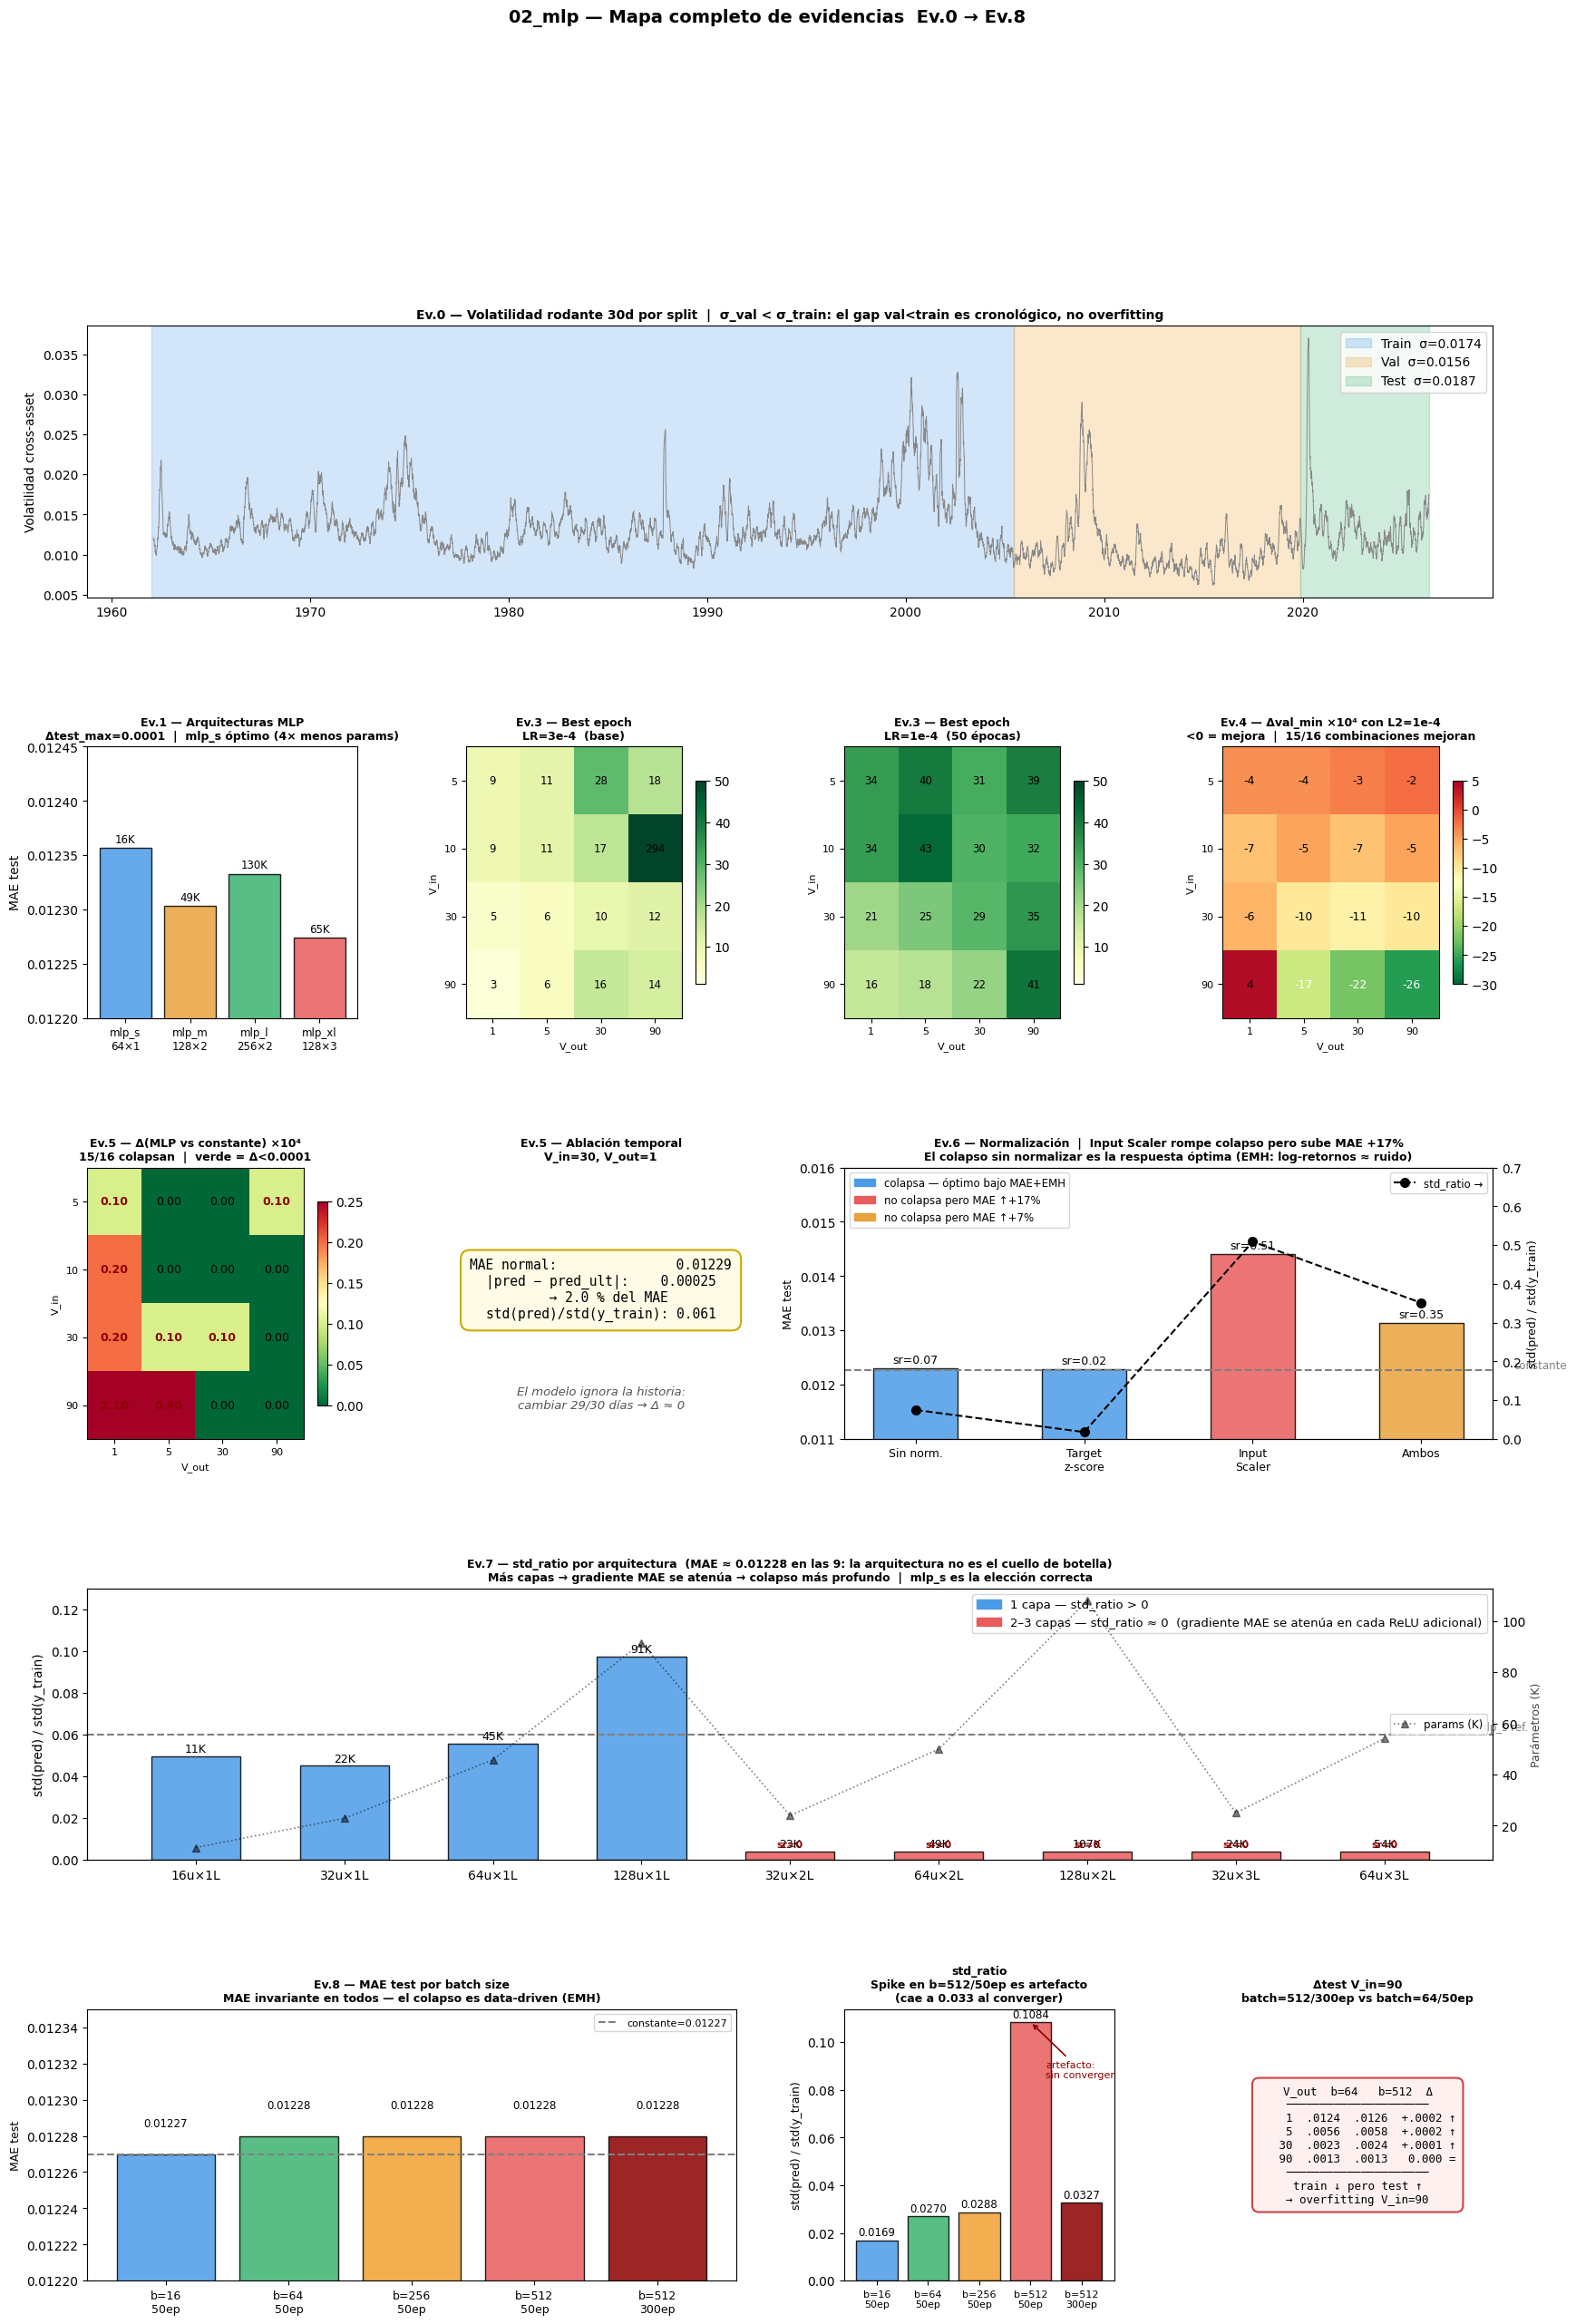

In [22]:
fig = plt.figure(figsize=(20, 28))
gs  = gridspec.GridSpec(5, 4, figure=fig, hspace=0.55, wspace=0.4)

# ══════════════════════════════════════════════════════════════════════════════
# Ev.0 — Partición temporal (justifica D4)
# ══════════════════════════════════════════════════════════════════════════════
ax0 = fig.add_subplot(gs[0, :])
n = len(returns)
n_tr, n_vl = int(n * 0.675), int(n * 0.225)
stds = {k: returns.iloc[s].values.std()
        for k, s in [('Train', slice(0, n_tr)),
                     ('Val',   slice(n_tr, n_tr+n_vl)),
                     ('Test',  slice(n_tr+n_vl, n))]}
vol = returns.std(axis=1).rolling(30).mean()
ax0.plot(returns.index, vol, color='#888888', lw=0.7)
for name, color, start, end in [('Train', '#4c9be8', 0, n_tr),
                                  ('Val',   '#f0a030', n_tr, n_tr+n_vl),
                                  ('Test',  '#3cb371', n_tr+n_vl, n)]:
    ax0.axvspan(returns.index[start], returns.index[end-1],
                alpha=0.25, color=color, label=f'{name}  σ={stds[name]:.4f}')
ax0.set_title('Ev.0 — Volatilidad rodante 30d por split  |  σ_val < σ_train: el gap val<train es cronológico, no overfitting',
              fontsize=10, fontweight='bold')
ax0.legend(fontsize=10); ax0.set_ylabel('Volatilidad cross-asset')

# ══════════════════════════════════════════════════════════════════════════════
# Ev.1 — Arquitecturas MLP (justifica D1)
# ══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[1, 0])
cfg1 = ['mlp_s\n64×1', 'mlp_m\n128×2', 'mlp_l\n256×2', 'mlp_xl\n128×3']
mae1 = [0.012357, 0.012303, 0.012333, 0.012274]
par1 = [16279, 49047, 130839, 65559]
clr1 = ['#4c9be8', '#e8a23c', '#3cb371', '#e85c5c']
brs1 = ax1.bar(range(4), mae1, color=clr1, edgecolor='k', alpha=0.85)
ax1.set_xticks(range(4)); ax1.set_xticklabels(cfg1, fontsize=8.5)
ax1.set_ylabel('MAE test'); ax1.set_ylim(0.01220, 0.01245)
for b, p in zip(brs1, par1):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.000005,
             f'{p//1000}K', ha='center', fontsize=8.5)
ax1.set_title('Ev.1 — Arquitecturas MLP\nΔtest_max=0.0001  |  mlp_s óptimo (4× menos params)', fontsize=9, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════════
# Ev.3 — Learning rate (justifica D7): best epoch con LR=3e-4 vs LR=1e-4
# ══════════════════════════════════════════════════════════════════════════════
V_ins_lbl, V_outs_lbl = [5, 10, 30, 90], [1, 5, 30, 90]
# best_base: experimento separado con LR=3e-4 (300 épocas) — hardcodeado
best_base = np.array([[ 9, 11, 28,  18], [ 9, 11, 17, 294], [ 5,  6, 10, 12], [ 3,  6, 16, 14]])
# best_var: valores reales de la ejecución actual con LR=1e-4
best_var  = np.array([[results[('mlp_s', Vi, Vo)]['best_epoch']
                       for Vo in V_outs_lbl]
                      for Vi in V_ins_lbl])
for col, (data, ttl) in enumerate([(best_base, 'LR=3e-4  (base)'), (best_var, f'LR=1e-4  ({EPOCHS} épocas)')]):
    ax3 = fig.add_subplot(gs[1, 1+col])
    im3 = ax3.imshow(data, cmap='YlGn', vmin=1, vmax=EPOCHS, aspect='auto')
    ax3.set_xticks(range(4)); ax3.set_xticklabels(V_outs_lbl, fontsize=8)
    ax3.set_yticks(range(4)); ax3.set_yticklabels(V_ins_lbl,  fontsize=8)
    ax3.set_xlabel('V_out', fontsize=8); ax3.set_ylabel('V_in', fontsize=8)
    for i in range(4):
        for j in range(4):
            ax3.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=8.5)
    ax3.set_title(f'Ev.3 — Best epoch\n{ttl}', fontsize=9, fontweight='bold')
    plt.colorbar(im3, ax=ax3, shrink=0.75)

# ══════════════════════════════════════════════════════════════════════════════
# Ev.4 — L2=1e-4 (justifica D8)
# ══════════════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 3])
dv4 = np.array([[-4,-4,-3,-2],[-7,-5,-7,-5],[-6,-10,-11,-10],[+4,-17,-22,-26]], dtype=float)
im4 = ax4.imshow(dv4, cmap='RdYlGn_r', vmin=-30, vmax=5, aspect='auto')
ax4.set_xticks(range(4)); ax4.set_xticklabels(V_outs_lbl, fontsize=8)
ax4.set_yticks(range(4)); ax4.set_yticklabels(V_ins_lbl,  fontsize=8)
ax4.set_xlabel('V_out', fontsize=8); ax4.set_ylabel('V_in', fontsize=8)
for i in range(4):
    for j in range(4):
        ax4.text(j, i, str(int(dv4[i,j])), ha='center', va='center', fontsize=9,
                 color='white' if dv4[i,j] < -12 else 'black')
plt.colorbar(im4, ax=ax4, shrink=0.75)
ax4.set_title('Ev.4 — Δval_min ×10⁴ con L2=1e-4\n<0 = mejora  |  15/16 combinaciones mejoran', fontsize=9, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════════
# Ev.5a — Heatmap colapso al predictor constante
# ══════════════════════════════════════════════════════════════════════════════
ax5a = fig.add_subplot(gs[2, 0])
d5 = np.array([[0.00001,0.00000,0.00000,0.00001],
               [0.00002,0.00000,0.00000,0.00000],
               [0.00002,0.00001,0.00001,0.00000],
               [0.00021,0.00004,0.00000,0.00000]]) * 1e4
im5a = ax5a.imshow(d5, cmap='RdYlGn_r', vmin=0, vmax=0.25, aspect='auto')
ax5a.set_xticks(range(4)); ax5a.set_xticklabels(V_outs_lbl, fontsize=8)
ax5a.set_yticks(range(4)); ax5a.set_yticklabels(V_ins_lbl,  fontsize=8)
ax5a.set_xlabel('V_out', fontsize=8); ax5a.set_ylabel('V_in', fontsize=8)
for i in range(4):
    for j in range(4):
        ax5a.text(j, i, f'{d5[i,j]:.2f}', ha='center', va='center', fontsize=9,
                  color='darkred' if d5[i,j] >= 0.1 else 'black',
                  fontweight='bold' if d5[i,j] >= 0.1 else 'normal')
plt.colorbar(im5a, ax=ax5a, shrink=0.75)
ax5a.set_title('Ev.5 — Δ(MLP vs constante) ×10⁴\n15/16 colapsan  |  verde = Δ<0.0001', fontsize=9, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════════
# Ev.5b — Ablación temporal
# ══════════════════════════════════════════════════════════════════════════════
ax5b = fig.add_subplot(gs[2, 1])
ax5b.axis('off')
ax5b.set_title('Ev.5 — Ablación temporal\nV_in=30, V_out=1', fontsize=9, fontweight='bold')
ax5b.text(0.5, 0.55,
          'MAE normal:               0.01229\n'
          '|pred − pred_ult|:    0.00025\n'
          '  → 2.0 % del MAE\n'
          'std(pred)/std(y_train): 0.061',
          ha='center', va='center', fontsize=10.5, fontfamily='monospace',
          transform=ax5b.transAxes,
          bbox=dict(boxstyle='round,pad=0.7', facecolor='#fffbe6', edgecolor='#ccaa00', lw=1.5))
ax5b.text(0.5, 0.15, 'El modelo ignora la historia:\ncambiar 29/30 días → Δ ≈ 0',
          ha='center', va='center', fontsize=9.5, style='italic',
          color='#555555', transform=ax5b.transAxes)

# ══════════════════════════════════════════════════════════════════════════════
# Ev.6 — Normalización (justifica D9)
# ══════════════════════════════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[2, 2:])
lbl6 = ['Sin norm.', 'Target\nz-score', 'Input\nScaler', 'Ambos']
mae6 = [0.01230, 0.01228, 0.01441, 0.01313]
rat6 = [0.0748,  0.0179,  0.5086,  0.3511]
clr6 = ['#4c9be8', '#4c9be8', '#e85c5c', '#e8a23c']
x6   = np.arange(4)
brs6 = ax6.bar(x6, mae6, color=clr6, edgecolor='k', alpha=0.85, width=0.5)
ax6.axhline(0.01227, color='gray', ls='--', lw=1.5)
ax6.text(3.55, 0.01230, 'constante', fontsize=8.5, color='gray')
ax6.set_xticks(x6); ax6.set_xticklabels(lbl6, fontsize=9)
ax6.set_ylabel('MAE test', fontsize=9); ax6.set_ylim(0.011, 0.016)
ax6r = ax6.twinx()
ax6r.plot(x6, rat6, 'k--o', ms=7, lw=1.5, label='std_ratio →')
ax6r.set_ylabel('std(pred) / std(y_train)', fontsize=9); ax6r.set_ylim(0, 0.7)
for b, r in zip(brs6, rat6):
    ax6.text(b.get_x()+b.get_width()/2, b.get_height()+0.0001,
             f'sr={r:.2f}', ha='center', fontsize=9)
p1 = mpatches.Patch(color='#4c9be8', label='colapsa — óptimo bajo MAE+EMH')
p2 = mpatches.Patch(color='#e85c5c', label='no colapsa pero MAE ↑+17%')
p3 = mpatches.Patch(color='#e8a23c', label='no colapsa pero MAE ↑+7%')
ax6.legend(handles=[p1, p2, p3], fontsize=8.5, loc='upper left')
ax6r.legend(fontsize=8.5, loc='upper right')
ax6.set_title('Ev.6 — Normalización  |  Input Scaler rompe colapso pero sube MAE +17%\n'
              'El colapso sin normalizar es la respuesta óptima (EMH: log-retornos ≈ ruido)', fontsize=9, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════════
# Ev.7 — Barrido de arquitecturas (justifica D10)
# ══════════════════════════════════════════════════════════════════════════════
ax7 = fig.add_subplot(gs[3, :])
arch7 = ['16u×1L','32u×1L','64u×1L','128u×1L','32u×2L','64u×2L','128u×2L','32u×3L','64u×3L']
rat7  = [0.0496, 0.0450, 0.0558, 0.0973, 0.0000, 0.0000, 0.0001, 0.0000, 0.0000]
par7  = [11447, 22871, 45719, 91415, 23927, 49879, 107927, 24983, 54039]
clr7  = ['#4c9be8']*4 + ['#e85c5c']*5
rat7_vis = [max(r, 0.004) for r in rat7]
brs7 = ax7.bar(range(9), rat7_vis, color=clr7, edgecolor='k', alpha=0.85, width=0.6)
ax7.axhline(0.06, color='gray', ls='--', lw=1.5)
ax7.text(8.62, 0.062, 'mlp_s ref.', fontsize=8.5, color='gray')
ax7.set_xticks(range(9)); ax7.set_xticklabels(arch7, fontsize=10)
ax7.set_ylabel('std(pred) / std(y_train)', fontsize=10)
ax7.set_ylim(0, 0.13)
ax7r = ax7.twinx()
ax7r.plot(range(9), [p/1000 for p in par7], 'k:^', ms=6, lw=1.2, alpha=0.5, label='params (K)')
ax7r.set_ylabel('Parámetros (K)', fontsize=9, color='#444444')
ax7r.legend(fontsize=8.5, loc='center right')
for b, p in zip(brs7, par7):
    h = max(b.get_height(), 0.003)
    ax7.text(b.get_x()+b.get_width()/2, h+0.002, f'{p//1000}K', ha='center', fontsize=9)
for i, (r, r_vis) in enumerate(zip(rat7, rat7_vis)):
    if r < 0.001:
        ax7.text(i, r_vis + 0.002, 'sr≈0', ha='center', fontsize=8, color='darkred', fontweight='bold')
p1 = mpatches.Patch(color='#4c9be8', label='1 capa — std_ratio > 0')
p2 = mpatches.Patch(color='#e85c5c', label='2–3 capas — std_ratio ≈ 0  (gradiente MAE se atenúa en cada ReLU adicional)')
ax7.legend(handles=[p1, p2], fontsize=9.5, loc='upper right')
ax7.set_title('Ev.7 — std_ratio por arquitectura  (MAE ≈ 0.01228 en las 9: la arquitectura no es el cuello de botella)\n'
              'Más capas → gradiente MAE se atenúa → colapso más profundo  |  mlp_s es la elección correcta', fontsize=9, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════════
# Ev.8 — Batch size (justifica D11)
# ══════════════════════════════════════════════════════════════════════════════
ax8a = fig.add_subplot(gs[4, 0:2])
cfg8  = ['b=16\n50ep', 'b=64\n50ep', 'b=256\n50ep', 'b=512\n50ep', 'b=512\n300ep']
mae8  = [0.01227,      0.01228,       0.01228,        0.01228,        0.01228]
clr8  = ['#4c9be8',   '#3cb371',     '#f0a030',      '#e85c5c',      '#8B0000']
brs8a = ax8a.bar(range(5), mae8, color=clr8, edgecolor='k', alpha=0.85)
ax8a.axhline(0.01227, color='gray', ls='--', lw=1.5, label='constante=0.01227')
ax8a.set_xticks(range(5)); ax8a.set_xticklabels(cfg8, fontsize=9)
ax8a.set_ylabel('MAE test', fontsize=9)
ax8a.set_ylim(0.01220, 0.01235)
for b, v in zip(brs8a, mae8):
    ax8a.text(b.get_x()+b.get_width()/2, b.get_height()+0.000015,
              f'{v:.5f}', ha='center', fontsize=8.5)
ax8a.legend(fontsize=8)
ax8a.set_title('Ev.8 — MAE test por batch size\nMAE invariante en todos — el colapso es data-driven (EMH)', fontsize=9, fontweight='bold')

ax8b = fig.add_subplot(gs[4, 2])
rat8 = [0.0169, 0.0270, 0.0288, 0.1084, 0.0327]
brs8b = ax8b.bar(range(5), rat8, color=clr8, edgecolor='k', alpha=0.85)
ax8b.set_xticks(range(5)); ax8b.set_xticklabels(cfg8, fontsize=8)
ax8b.set_ylabel('std(pred) / std(y_train)', fontsize=9)
for b, v in zip(brs8b, rat8):
    ax8b.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
              f'{v:.4f}', ha='center', fontsize=8.5)
ax8b.annotate('artefacto:\nsin converger', xy=(3, 0.1084), xytext=(3.3, 0.085),
              fontsize=8, color='darkred',
              arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2))
ax8b.set_title('std_ratio\nSpike en b=512/50ep es artefacto\n(cae a 0.033 al converger)', fontsize=9, fontweight='bold')

ax8c = fig.add_subplot(gs[4, 3])
ax8c.axis('off')
ax8c.set_title('Δtest V_in=90\nbatch=512/300ep vs batch=64/50ep', fontsize=9, fontweight='bold')
tabla = (
    'V_out  b=64   b=512  Δ\n'
    '─────────────────────\n'
    '    1  .0124  .0126  +.0002 ↑\n'
    '    5  .0056  .0058  +.0002 ↑\n'
    '   30  .0023  .0024  +.0001 ↑\n'
    '   90  .0013  .0013   0.000 =\n'
    '─────────────────────\n'
    'train ↓ pero test ↑\n→ overfitting V_in=90'
)
ax8c.text(0.5, 0.5, tabla, ha='center', va='center', fontsize=9,
          fontfamily='monospace', transform=ax8c.transAxes,
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#fff0f0', edgecolor='#cc4444', lw=1.5))

plt.suptitle('02_mlp — Mapa completo de evidencias  Ev.0 → Ev.8', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()